In [7]:
import pandas as pd
df = pd.read_csv('student_performance.csv')
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

# 2. CALCULATE STATISTICAL METRICS (Mean, Median, Mode)
mean_hours = df_sample['weekly_self_study_hours'].mean()
median_hours = df_sample['weekly_self_study_hours'].median()
mode_hours = df_sample['weekly_self_study_hours'].mode().iloc[0] 

mean_score = df_sample['total_score'].mean()
median_score = df_sample['total_score'].median()
mode_score = df_sample['total_score'].mode().iloc[0]
summary_table = pd.DataFrame({
    'Statistical Metric': ['Mean (Average)', 'Median (Middle Value)', 'Mode (Most Frequent)'],
    'Weekly Self Study Hours': [f"{mean_hours:.2f}", f"{median_hours:.2f}", f"{mode_hours:.2f}"],
    'Total Score': [f"{mean_score:.2f}", f"{median_score:.2f}", f"{mode_score:.2f}"]
})

print("=" * 60)
print("              DESCRIPTIVE STATISTICS SUMMARY")
print("=" * 60)
print(summary_table.to_string(index=False))
print("=" * 60)
print("\n")
print("=" * 60)
print(f"        RAW DATA TABLE USED IN PROJECT (First 20 Rows)")
print("=" * 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
print(df_sample[['weekly_self_study_hours', 'total_score']].head(20).to_string())
print("=" * 60)

              DESCRIPTIVE STATISTICS SUMMARY
   Statistical Metric Weekly Self Study Hours Total Score
       Mean (Average)                   15.04       84.39
Median (Middle Value)                   14.95       87.50
 Mode (Most Frequent)                    0.00      100.00


        RAW DATA TABLE USED IN PROJECT (First 20 Rows)
    weekly_self_study_hours  total_score
0                       3.9         53.9
1                      17.1         77.3
2                       8.7         75.0
3                      15.0         85.7
4                       0.9         30.8
5                       3.8         62.3
6                       4.1         74.0
7                       4.2         68.9
8                      15.5         83.7
9                      12.5         95.5
10                     17.3         95.9
11                     14.8         81.0
12                     24.0        100.0
13                     15.9         97.1
14                     12.6         62.3
15        

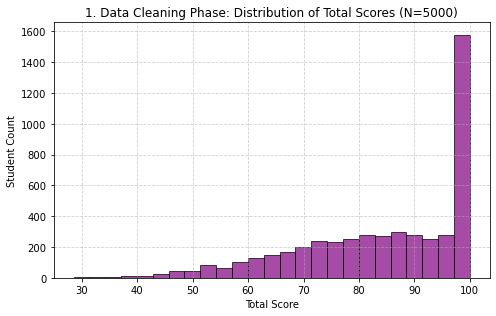

Graph 1 successfully saved as '1_data_cleaning.png'


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and sample 5,000 rows
df = pd.read_csv('student_performance.csv')
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
plt.figure(figsize=(7, 4.5))
plt.hist(df_sample['total_score'], bins=25, color='purple', edgecolor='black', alpha=0.7)
plt.title('1. Data Cleaning Phase: Distribution of Total Scores (N=5000)')
plt.xlabel('Total Score')
plt.ylabel('Student Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig('1_data_cleaning.png')
plt.show()
plt.close()
print("Graph 1 successfully saved as '1_data_cleaning.png'")

Total Rows Shuffled: 5000
Training Rows Extracted (80%): 4000


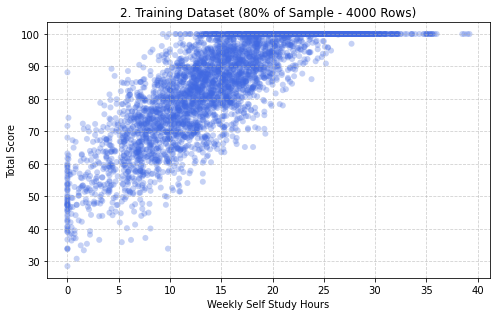

Graph 2 successfully saved as '2_training_data.png'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load, sample 5,000, and shuffle data
df = pd.read_csv('student_performance.csv')
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
df_shuffled = df_sample.sample(frac=1, random_state=1).reset_index(drop=True)

split_point = int(0.8 * len(df_shuffled))
train_data = df_shuffled.iloc[:split_point]  # 4000 rows used for learning
test_data = df_shuffled.iloc[split_point:]   # 1000 rows held for testing

print(f"Total Rows Shuffled: {len(df_shuffled)}")
print(f"Training Rows Extracted (80%): {len(train_data)}")

plt.figure(figsize=(7, 4.5))
# Faded alpha to 0.3 because 4,000 points are very dense
plt.scatter(train_data['weekly_self_study_hours'], train_data['total_score'], 
            color='royalblue', alpha=0.3, edgecolors='none')
plt.title('2. Training Dataset (80% of Sample - 4000 Rows)')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('2_training_data.png')
plt.show()
plt.close()
print("Graph 2 successfully saved as '2_training_data.png'")

Testing Rows Extracted (20%): 1000


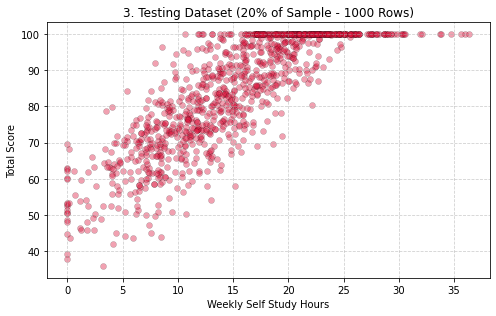

Graph 3 successfully saved as '3_testing_data.png'


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load, sample 5,000, shuffle, and split data
df = pd.read_csv('student_performance.csv')
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
df_shuffled = df_sample.sample(frac=1, random_state=1).reset_index(drop=True)

split_point = int(0.8 * len(df_shuffled))
test_data = df_shuffled.iloc[split_point:]   # 1000 validation rows

print(f"Testing Rows Extracted (20%): {len(test_data)}")

plt.figure(figsize=(7, 4.5))
plt.scatter(test_data['weekly_self_study_hours'], test_data['total_score'], 
            color='crimson', alpha=0.4, edgecolors='black', linewidths=0.3)
plt.title('3. Testing Dataset (20% of Sample - 1000 Rows)')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and Show Chart
plt.savefig('3_testing_data.png')
plt.show()
plt.close()
print("Graph 3 successfully saved as '3_testing_data.png'")

REGRESSION PERFORMANCE EVALUATION SUMMARY (N=5000):
Calculated R-squared (R²) Accuracy Score: 0.6573 (65.73%)


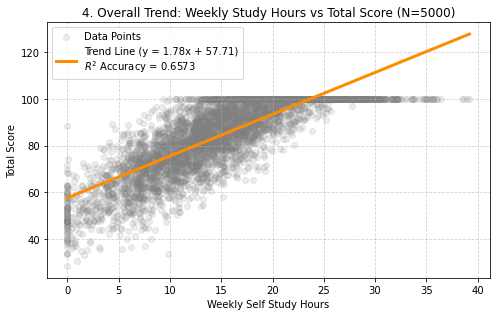


Graph 4 successfully saved with R² metric as '4_trend_line_with_r2.png'!
Predictive Model Formula: Final Score = (1.78 * Study Hours) + 57.71


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('student_performance.csv')
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
df_shuffled = df_sample.sample(frac=1, random_state=1).reset_index(drop=True)
split_point = int(0.8 * len(df_shuffled))
train_data = df_shuffled.iloc[:split_point]


correlation_matrix = np.corrcoef(train_data['weekly_self_study_hours'], train_data['total_score'])
r_value = correlation_matrix[0, 1]
r_squared = r_value ** 2  # Square the correlation to get the R² coefficient

print("=" * 60)
print(f"REGRESSION PERFORMANCE EVALUATION SUMMARY (N=5000):")
print(f"Calculated R-squared (R²) Accuracy Score: {r_squared:.4f} ({r_squared * 100:.2f}%)")
print("=" * 60)


plt.figure(figsize=(7, 4.5))

plt.scatter(df_sample['weekly_self_study_hours'], df_sample['total_score'], 
            color='gray', alpha=0.15, label='Data Points')

m, c = np.polyfit(train_data['weekly_self_study_hours'], train_data['total_score'], 1)

x_line = np.linspace(df_sample['weekly_self_study_hours'].min(), df_sample['weekly_self_study_hours'].max(), 100)
y_line = m * x_line + c

plt.plot(x_line, y_line, color='darkorange', linewidth=3, 
         label=f'Trend Line (y = {m:.2f}x + {c:.2f})\n$R^2$ Accuracy = {r_squared:.4f}')

plt.title('4. Overall Trend: Weekly Study Hours vs Total Score (N=5000)')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and Show Chart
plt.savefig('4_trend_line_with_r2.png')
plt.show()
plt.close()

print(f"\nGraph 4 successfully saved with R² metric as '4_trend_line_with_r2.png'!")
print(f"Predictive Model Formula: Final Score = ({m:.2f} * Study Hours) + {c:.2f}")